# Amazon Laptop Scraping

In [32]:
# import libraries
import re
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
#!pip install beautifulsoup4 requests pandas

In [34]:
# take the url of the page
url = "https://www.amazon.in/s?k=laptops&crid=3R9WE5K6F9ZLA&sprefix=laptops%2Caps%2C522&ref=nb_sb_noss_2"

In [35]:
# create the request header

headers = {
    "User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36"
}


In [36]:
# send the request
response = requests.get(url, headers=headers)

# check if the request was successful
response.status_code

200

In [37]:
# show the content of the page
response.content

b'<!doctype html><html lang="en-in" class="a-no-js" data-19ax5a9jf="dingo"><!-- sp:feature:head-start -->\n<head><script>var aPageStart = (new Date()).getTime();</script><meta charset="utf-8"/>\n<!-- sp:end-feature:head-start -->\n<!-- sp:feature:csm:head-open-part1 -->\n\n<script type=\'text/javascript\'>var ue_t0=ue_t0||+new Date();</script>\n<!-- sp:end-feature:csm:head-open-part1 -->\n<!-- sp:feature:cs-optimization -->\n<meta http-equiv=\'x-dns-prefetch-control\' content=\'on\'>\n<link rel="preconnect" href="https://images-eu.ssl-images-amazon.com" crossorigin>\n<link rel="preconnect" href="https://m.media-amazon.com" crossorigin>\n<!-- sp:end-feature:cs-optimization -->\n<!-- sp:feature:csm:head-open-part2 -->\n<script type=\'text/javascript\'>\nwindow.ue_ihb = (window.ue_ihb || window.ueinit || 0) + 1;\nif (window.ue_ihb === 1) {\n\nvar ue_csm = window,\n    ue_hob = +new Date();\n(function(d){var e=d.ue=d.ue||{},f=Date.now||function(){return+new Date};e.d=function(b){return f()

In [86]:
# beautiful soup object

bs = BeautifulSoup(response.content, "html.parser")


In [39]:
list_data = []

for page in range(1, 30):
    params = {"k": "laptops", "page": page}
    response = requests.get(url, headers=headers, params=params, timeout=30)
    response.raise_for_status()
    bs = BeautifulSoup(response.text, "html.parser")

    product_containers = bs.select('div[data-component-type="s-search-result"]')

    for product in product_containers:

        title_tag = product.select_one("h2 span")
        if not title_tag:
            continue

        #Step 1:Extract the Title
        title = title_tag.get_text(" ", strip=True)

        # Step 2: Extract the Price
        price_tag = product.select_one("span.a-price-whole")

        # Step 3: Extract the Rating
        rating_tag = product.select_one("span.a-size-small.a-color-base")
        match = re.match(r"([A-Za-z]+)", title)


        #Step 5: Extract the Brand Name
        brand = match.group(1) if match else "Unknown"
        
        #Step 6: Extract the RAM
        match = re.search(r"(\d+GB|RAM\s*(\d+GB)?|DDR\d?\s*(\d+GB)?|LPDDR\d?\s*(\d+GB)?)", title, re.IGNORECASE)
        ram = match.group(1) if match else "N/A"

        #Step 7: Extract the Storage 
        match = re.search(r"(\d+)\s*(GB|TB)\s*(?:SSD|Storage|HDD)", title, re.IGNORECASE)
        ssd_storage = f"{match.group(1)}{match.group(2)}" if match else "N/A"

        #Step 8: Extract the Color
        match = re.search(r"\b(Black|White|Silver|Gray|Grey|Red|Blue|Green|Yellow|Pink|Purple|Gold|Bronze|Rose Gold|Indigo|Glacier)\b", title, re.IGNORECASE)
        color = match.group(1) if match else "N/A"
       
        # Step 9: Extract the processor information
        # Step 7: Extract the processor (Intel, AMD, Apple M/A chip, Snapdragon, MediaTek, etc)
        processor = "N/A"
        # Try to match Apple M series (M1, M2, M3, M4, M5, etc.)
        match = re.search(r"Apple\s+M(\d+)", title, re.IGNORECASE)
        if match:
            processor = f"Apple M{match.group(1)}"
        else:
            # Try to match Apple A series (A18, A17, A16, etc.)
            match = re.search(r"Apple\s+A(\d+)", title, re.IGNORECASE)
            if match:
                processor = f"Apple A{match.group(1)}"
            else:
                # Try other processor keywords
                processor_keywords = ["Intel", "AMD", "Snapdragon", "MediaTek", "Celeron"]
                for keyword in processor_keywords:
                    if re.search(rf"\b{keyword}\b", title, re.IGNORECASE):
                        processor = keyword
                        break

        # Append the extracted data to the list
        list_data.append({
            "title": title,
            "price": price_tag.get_text(strip=True) if price_tag else "N/A",
            "rating": rating_tag.get_text(strip=True) if rating_tag else "N/A",
            "brand": brand,
            "ram": ram,
            "storage": ssd_storage,
            "color": color,
            "processor": processor
            })

In [40]:
# display the data item 

for item in list_data:
    print(f"Title: {item['title']}")
    print(f"Price: {item['price']}")
    print(f"Rating: {item['rating']}")
    print(f"Brand: {item['brand']}")
    print(f"RAM: {item['ram']}")
    print(f"Storage: {item['storage']}")
    print(f"Color: {item['color']}")
    print(f"Processor: {item['processor']}")
    print("-" * 50)

Title: HP Omnibook 3, Snapdragon X Processor 45 Tops (16GB LPDDR5x,512GB SSD) 2K WUXGA, 14''/35.6cm, Win 11, M365*Office 24,Silver,1.42kg, hz0026QU/ hz0024QU, Lighter mini Charger, FHD IR Camera, AI Laptop
Price: 69,990
Rating: 3.4
Brand: HP
RAM: 16GB
Storage: 512GB
Color: Silver
Processor: Snapdragon
--------------------------------------------------
Title: HP OmniBook 5 OLED (Previously Pavilion), Snapdragon X Processor 45 Tops (16GB LPDDR5x, 512GB SSD), 2K 14''/35.6cm, Win11, Office24, Silver, 1.29kg, he0014QU, Multi-Day Battery, AI Laptop
Price: 79,990
Rating: 4.1
Brand: HP
RAM: 16GB
Storage: 512GB
Color: Silver
Processor: Snapdragon
--------------------------------------------------
Title: Lenovo V15 G4 AMD Athlon Silver 7120U Laptop 8GB LPDDR5 Ram, 512 GB SSD PCIe, Windows 11 Lifetime Validity,15.6" FHD Screen, AMD Radeon 610M, Silver, 1 Year Brand Warranty
Price: 44,999
Rating: 4.0
Brand: Lenovo
RAM: 8GB
Storage: 512GB
Color: Silver
Processor: AMD
-------------------------------

In [41]:
# check the length of the data
print(f"Total number of laptops scraped: {len(list_data)}")

Total number of laptops scraped: 497


In [42]:
# display the match
print(brand)

Lenovo


In [43]:
# Saved the data to csv file
df= pd.DataFrame(list_data)


In [44]:
# Save the data to a csv file
df.to_csv("amazon_laptops.csv",index=False)

# Clean the data and save as a separate file

In [45]:
# Read the Data set
df=pd.read_csv("amazon_laptops.csv")

In [46]:
#copy of the original data

df_clean = df.copy()

In [47]:
# Remove duplicate records

df_clean.drop_duplicates(inplace=True)

In [48]:
print(f"Total number of laptops: {len(df_clean)}")

Total number of laptops: 285


In [49]:
#Remove the title column

df_clean.drop(columns=["title"], inplace=True, errors="ignore")

In [50]:
# Convert storage TB to GB
def storage_to_gb(value):
    if pd.isna(value):
        return np.nan

    value = str(value).upper()
    number = float(re.search(r"(\d+(?:\.\d+)?)", value).group(1))

    return int(number * 1024) if "TB" in value else int(number)

# Apply conversion
df_clean["storage"] = df_clean["storage"].apply(storage_to_gb)

In [51]:
# CLEAN PRICE
df_clean["price"] = (df_clean["price"].astype(str).str.replace(",", "", regex=False).str.replace(r"[^\d.]", "", regex=True))

# Convert price into numeric values
df_clean["price"] = pd.to_numeric(df_clean["price"],errors="coerce")

In [52]:
#CLEAN RAM
df_clean["ram"] = (df_clean["ram"].astype(str).str.extract(r"(\d+)")[0])

df_clean["ram"] = pd.to_numeric(df_clean["ram"],errors="coerce")

In [53]:
#REPLACE MISSING NUMERIC VALUES WITH MODE
numeric_columns = ["price","rating","ram","storage"]

for column in numeric_columns:

    # Calculate mode
    mode_value = df_clean[column].mode()

    # Only fill if a mode exists
    if not mode_value.empty:
        df_clean[column] = df_clean[column].fillna( mode_value.iloc[0])

In [54]:
# REPLACE MISSING CATEGORICAL VALUES WITH MODE
categorical_columns = ["brand","color","processor"]

for column in categorical_columns:

    if column in df_clean.columns:

        mode_value = df_clean[column].mode()

        if not mode_value.empty:
            df_clean[column] = df_clean[column].fillna(mode_value.iloc[0])

In [55]:
 #CONVERT NUMERICAL COLUMNS INTO INTEGER

df_clean["price"] = df_clean["price"].round().astype(int)

df_clean["rating"] = df_clean["rating"].round().astype(int)

df_clean["ram"] = df_clean["ram"].round().astype(int)

df_clean["storage"] = df_clean["storage"].round().astype(int)


In [57]:
#SAVE ORIGINAL CATEGORY NAMES BEFORE ENCODING
# Brand
brand_codes, brand_names = pd.factorize(df_clean["brand"],sort=True)

brand_mapping = dict(enumerate(brand_names))

df_clean["brand"] = brand_codes.astype(int)


# Color
color_codes, color_names = pd.factorize(df_clean["color"],sort=True)

color_mapping = dict(enumerate(color_names))

df_clean["color"] = color_codes.astype(int)


# Processor
processor_codes, processor_names = pd.factorize(df_clean["processor"],sort=True)

processor_mapping = dict(enumerate(processor_names))

df_clean["processor"] = processor_codes.astype(int)

In [58]:
df_clean

,price,rating,brand,ram,storage,color,processor
0,69990,3,8,16,512,6,4
1,79990,4,8,16,512,6,4
2,44999,4,10,8,512,6,0
3,42990,4,1,16,512,2,0
4,73990,5,3,8,256,6,2
...,...,...,...,...,...,...,...
454,103990,4,10,16,1024,4,2
455,99565,2,16,16,1024,6,2
456,349990,5,7,64,2048,6,2
463,513990,2,3,36,2048,6,2


In [59]:
 # SAVE CLEANED DATA AS A SEPARATE FILE

df_clean.to_csv("cleaned_amazon_laptops.csv",index=False)

print("\nCleaned data saved as cleaned_amazon_laptops.csv")


Cleaned data saved as cleaned_amazon_laptops.csv


In [88]:

print(df_clean.head())
print(df_clean.columns.tolist())


   price  rating  brand  ram  storage  color  processor
0  69990       3      8   16      512      6          4
1  79990       4      8   16      512      6          4
2  44999       4     10    8      512      6          0
3  42990       4      1   16      512      2          0
4  73990       5      3    8      256      6          2
['price', 'rating', 'brand', 'ram', 'storage', 'color', 'processor']


### 10 visualizations using the cleaned data.

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = pd.read_csv("cleaned_amazon_laptops.csv")

# Remove unwanted column names
df_clean.columns = df_clean.columns.str.strip()

# Check the column names
print(df_clean.columns.tolist())

['price', 'rating', 'brand', 'ram', 'storage', 'color', 'processor']


1. Distribution of Laptop Prices

Explanation:
This histogram shows how laptop prices are distributed in the cleaned dataset. It helps identify the price range in which most laptops are available. The KDE line shows the overall shape and concentration of the price distribution.

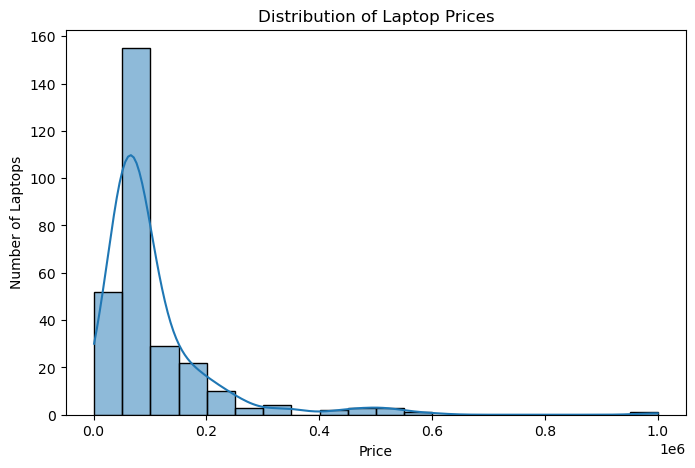

In [93]:
# Clean column names
df_clean.columns = df_clean.columns.str.strip().str.lower()

# Convert price column to numeric
df_clean["price"] = pd.to_numeric(df_clean["price"], errors="coerce")

# Remove rows where price is missing
price_data = df_clean.dropna(subset=["price"])

# Create histogram
plt.figure(figsize=(8,5))

sns.histplot(
    data=price_data,
    x="price",
    bins=20,
    kde=True
)

plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Number of Laptops")

plt.show()

2. Top 10 Laptop Brands

Explanation:
This bar chart shows the top 10 laptop brands based on the number of laptop listings in the dataset. A longer bar indicates that the brand has more laptop models available.

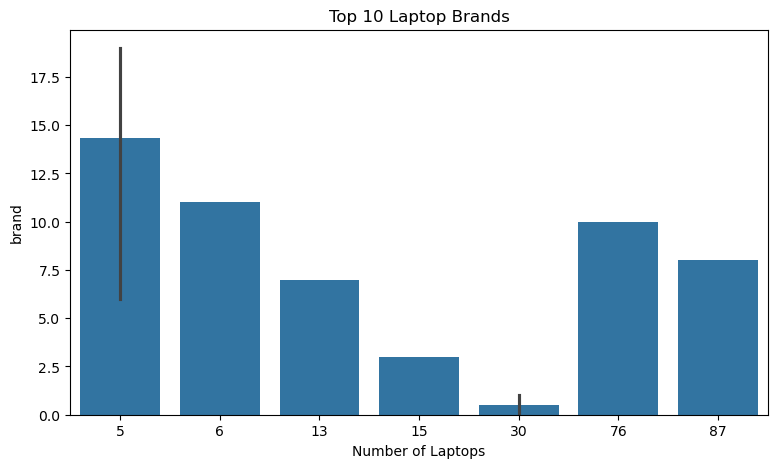

In [94]:
# Bar chart
top_brands = df_clean["brand"].value_counts().head(10)

plt.figure(figsize=(9,5))

sns.barplot(x=top_brands.values,y=top_brands.index)

plt.title("Top 10 Laptop Brands")
plt.xlabel("Number of Laptops")
plt.ylabel("brand")

plt.show()

3. Average Laptop Price by Brand

Explanation:
This visualization compares the average price of laptops from different brands. It helps identify which brands generally offer more expensive or premium laptops.

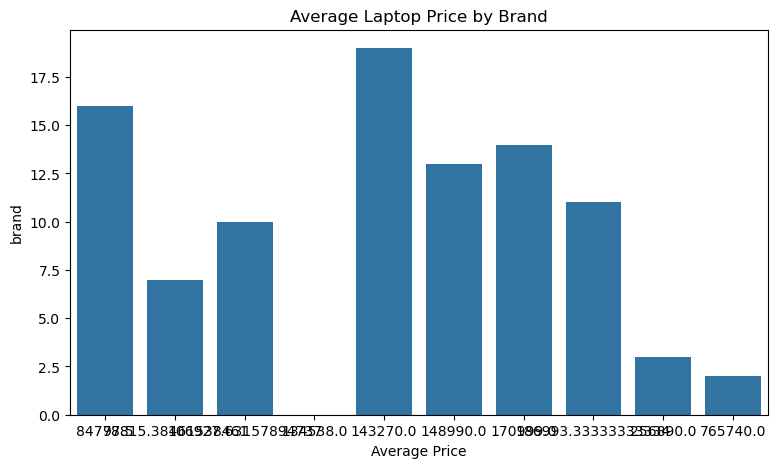

In [95]:
brand_price = (df_clean.groupby("brand")["price"].mean().sort_values(ascending=False).head(10))

plt.figure(figsize=(9,5))

sns.barplot(x=brand_price.values,y=brand_price.index)

plt.title("Average Laptop Price by Brand")
plt.xlabel("Average Price")
plt.ylabel("brand")

plt.show()

4. Distribution of Customer Ratings

Explanation:
This histogram shows the distribution of customer ratings for laptops. It helps determine whether most laptops have high, medium, or low customer ratings.

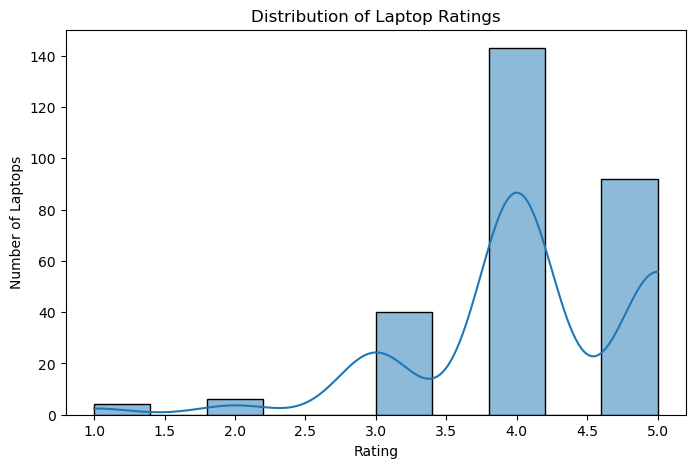

In [100]:
# Convert rating column to numeric
df_clean["rating"] = pd.to_numeric(df_clean["rating"], errors="coerce")

# Remove missing rating values
rating_data = df_clean.dropna(subset=["rating"])

# Create histogram
plt.figure(figsize=(8,5))

sns.histplot(data=rating_data,x="rating",bins=10,kde=True)

plt.title("Distribution of Laptop Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Laptops")

plt.show()

5. Laptop Price vs Customer Rating

Explanation:
This scatter plot shows the relationship between laptop price and customer rating. Each point represents one laptop. It can be used to check whether more expensive laptops tend to receive higher ratings.

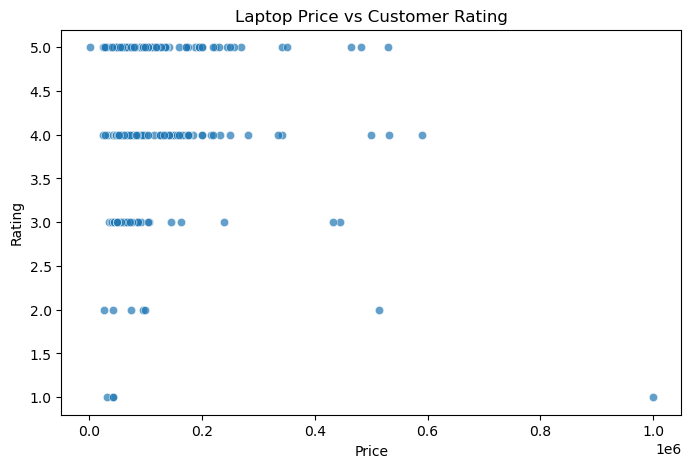

In [102]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df_clean,x="price",y="rating",alpha=0.7)

plt.title("Laptop Price vs Customer Rating")
plt.xlabel("Price")
plt.ylabel("Rating")

plt.show()

6. Laptop Listings by RAM Capacity

Explanation:
This bar chart shows the number of laptops available with different RAM capacities such as 4 GB, 8 GB, 16 GB and 32 GB. It helps identify the most common RAM configuration.

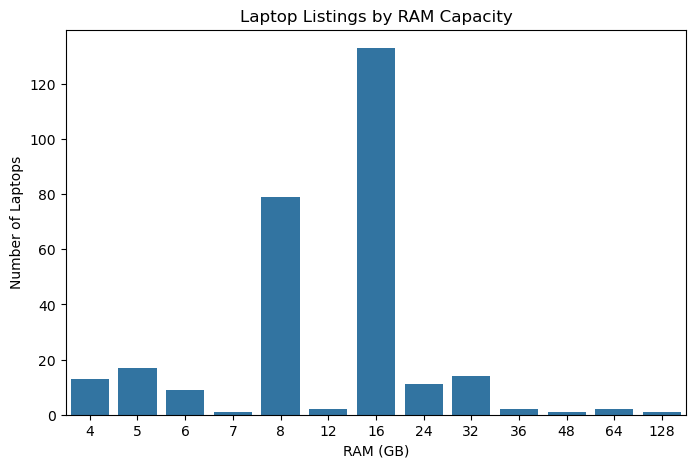

In [101]:
# Bar chart
ram_counts = df_clean["ram"].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(x=ram_counts.index,y=ram_counts.values)

plt.title("Laptop Listings by RAM Capacity")
plt.xlabel("RAM (GB)")
plt.ylabel("Number of Laptops")

plt.show()

7. Average Laptop Price by RAM

Explanation:
This graph compares the average laptop price for different RAM capacities. It helps determine whether laptops with higher RAM generally cost more.

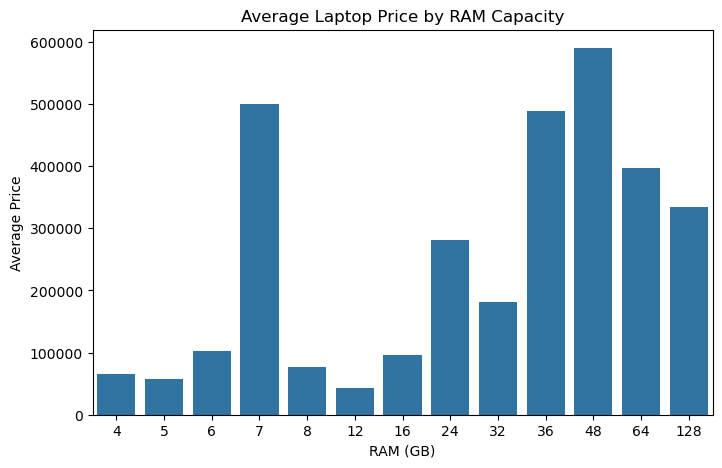

In [103]:
ram_price = (df_clean.groupby("ram")["price"].mean().reset_index().sort_values("ram"))

plt.figure(figsize=(8,5))

sns.barplot(data=ram_price,x="ram",y="price")

plt.title("Average Laptop Price by RAM Capacity")
plt.xlabel("RAM (GB)")
plt.ylabel("Average Price")

plt.show()

8. Processor Family Distribution

Explanation:
This bar chart shows the number of laptops using different processor families such as Intel, AMD, Apple Silicon and Qualcomm. It helps identify which processor family is most common in the dataset.

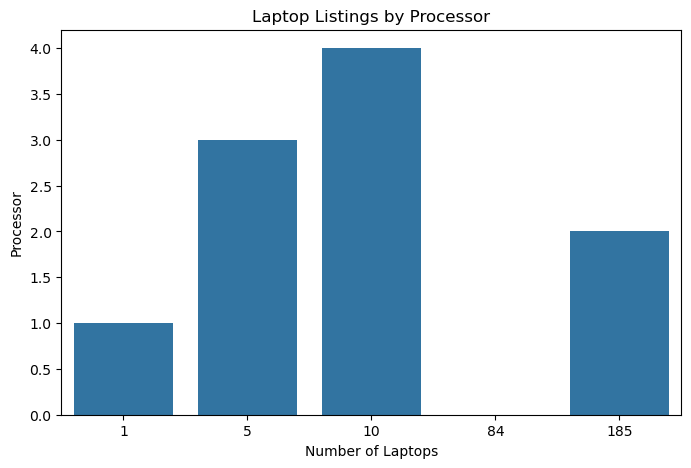

In [104]:
processor_counts = (df_clean["processor"].value_counts().reset_index())

processor_counts.columns = ["processor", "Count"]

plt.figure(figsize=(8,5))

sns.barplot(data=processor_counts,x="Count",y="processor")

plt.title("Laptop Listings by Processor")
plt.xlabel("Number of Laptops")
plt.ylabel("Processor")

plt.show()

9. Storage Capacity Distribution

Explanation:
This visualization shows how many laptops are available with different storage capacities such as 256 GB, 512 GB and 1 TB. It helps identify the most common storage option.

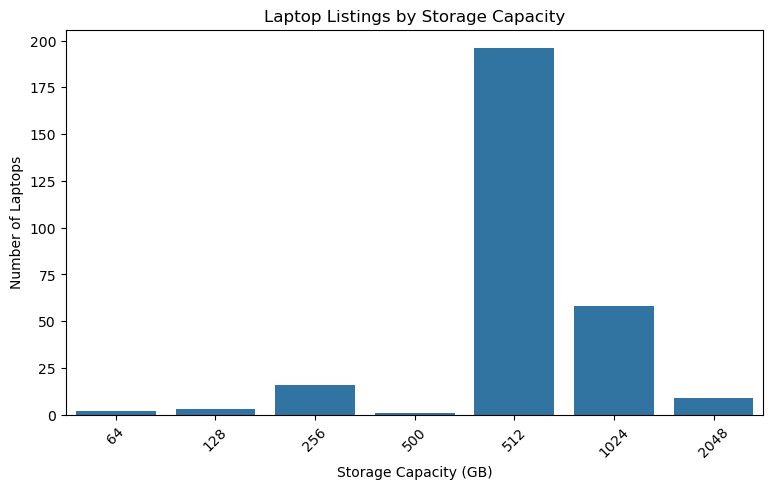

In [105]:
storage_counts = (df_clean["storage"].value_counts().sort_index().reset_index())

storage_counts.columns = ["storage", "Count"]

plt.figure(figsize=(9,5))

sns.barplot(data=storage_counts,x="storage",y="Count")

plt.title("Laptop Listings by Storage Capacity")
plt.xlabel("Storage Capacity (GB)")
plt.ylabel("Number of Laptops")

plt.xticks(rotation=45)

plt.show()

10. Average Customer Rating by Brand

Explanation:
This bar chart compares the average customer ratings of the top laptop brands. It helps identify which brands receive better customer feedback and higher satisfaction ratings.

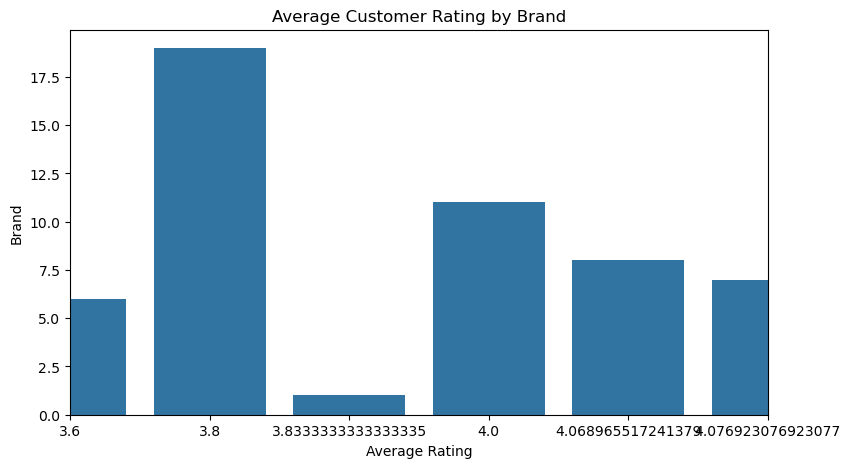

In [106]:
top_brand_names = df_clean["brand"].value_counts().head(10).index

brand_rating = (df_clean[df_clean["brand"].isin(top_brand_names)].groupby("brand")["rating"].mean().reset_index()
    .sort_values("rating", ascending=False))

plt.figure(figsize=(9,5))

sns.barplot(data=brand_rating,x="rating",y="brand")

plt.title("Average Customer Rating by Brand")
plt.xlabel("Average Rating")
plt.ylabel("Brand")

plt.xlim(0,5)

plt.show()